In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential,model_from_json
from keras.layers import Conv2D , MaxPooling2D , Flatten ,Dense ,Dropout
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import urllib

In [ ]:

input_shape_2D = (224,224)
input_shape_3D = (224,224,3)
seed = 1
batch_size = 5
epochs = 30



## LOADING THE DATA


In [ ]:
data = tf.keras.utils.image_dataset_from_directory(directory="/content/drive/MyDrive/rice_leaf_data/rice_leaf_data",
                                                  labels='inferred',
                                                  label_mode='int',
                                                  color_mode='rgb',
                                                  image_size=input_shape_2D,
                                                  seed=seed)

Found 119 files belonging to 3 classes.


## The 3 Classes are - Bacterial leaf blight, Brown spot, Leaf smut

In [ ]:


# print class names

class_names = data.class_names
class_names

['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

In [ ]:

# Initialize an empty dictionary to store class counts
class_counts = {}

# Iterate through the dataset to count occurrences of each class label
for images, labels in data:
    for label in labels:
        class_counts[label.numpy()] = class_counts.get(label.numpy(), 0) + 1

# Print the class counts
print(class_counts)


{np.int32(0): 40, np.int32(1): 40, np.int32(2): 39}


## Image  Visualisation

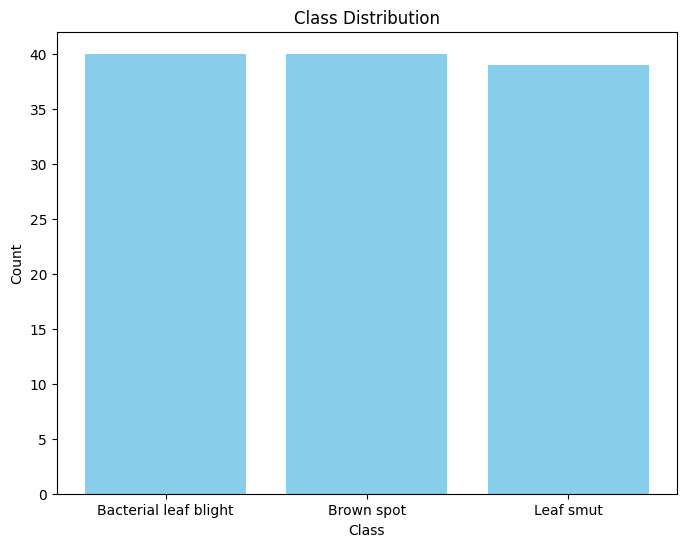

In [ ]:


# Class names and counts
class_names = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
class_counts = [40, 40, 39]  # Replace with your actual counts

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(class_names, class_counts, color='skyblue')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [ ]:
#From the graph we can clearly see that there are a total of 119 images.
#40 in Bacterial Leaf Blight and Brown Spot.
#39 images available in Leaf Smut.

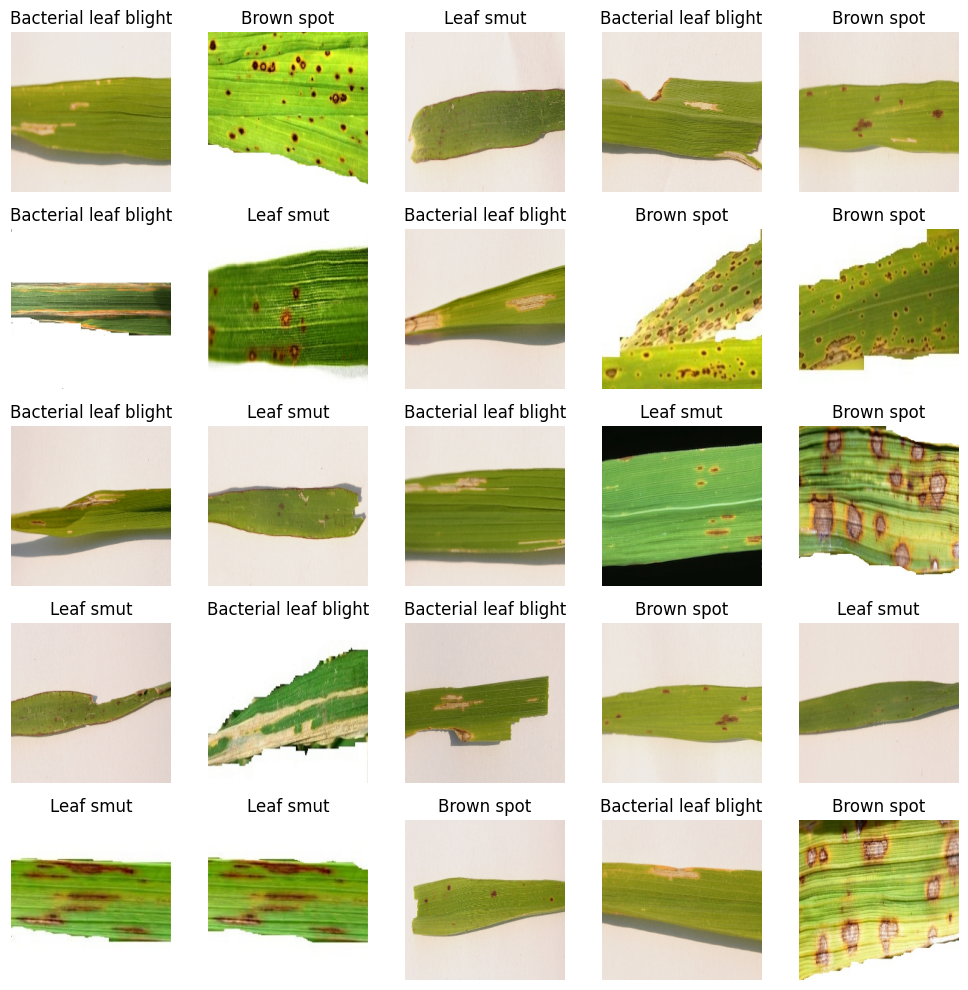

In [ ]:

plt.figure(figsize=(10,10))
for images , labels in data.take(1):
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
    plt.tight_layout()

# These are the inputs of our model

In [ ]:
# Create Dependent(y) and Independent(X) variable

X = []
y = []

for images , labels in data:
    X.append(images.numpy())
    y.append(labels.numpy())


# convert X , y list into numpy array

X = np.concatenate(X ,axis=0)
y = np.concatenate(y ,axis=0)



In [ ]:
X

array([[[[  4.761161 ,   9.761161 ,   3.7611609],
         [  5.566964 ,   9.716518 ,   4.       ],
         [  9.417412 ,  10.611608 ,   5.6116076],
         ...,
         [  6.       ,  11.       ,   5.       ],
         [  8.       ,  10.       ,   5.       ],
         [  8.       ,  10.       ,   5.       ]],

        [[  4.761161 ,   9.761161 ,   3.7611609],
         [  5.566964 ,   9.716518 ,   4.       ],
         [  9.417412 ,  10.611608 ,   5.6116076],
         ...,
         [  6.       ,  11.       ,   5.       ],
         [  8.       ,  10.       ,   5.       ],
         [  8.       ,  10.       ,   5.       ]],

        [[  4.761161 ,   9.761161 ,   3.7611609],
         [  5.566964 ,   9.716518 ,   4.       ],
         [  9.417412 ,  10.611608 ,   5.6116076],
         ...,
         [  6.       ,  11.       ,   5.       ],
         [  8.       ,  10.       ,   5.       ],
         [  8.       ,  10.       ,   5.       ]],

        ...,

        [[ 10.238839 ,  11.238839 ,   

In [ ]:
X =X.astype('float32')/255

# spliting Dataset into Train and Test /validation  data

In [ ]:

# Splitt data into train and test / validation

X_train, X_test = X[:95 ],X[95:]
y_train, y_test = y[:95] ,y[95:]

In [ ]:
X_train.shape , X_test.shape


((95, 224, 224, 3), (24, 224, 224, 3))

In [ ]:
# Convert labels to one-hot encoding
y_train = to_categorical(y_train ,len(class_names))
y_test = to_categorical(y_test ,len(class_names))


# Model Creation

In [ ]:
# relu - the usage of ReLU helps to prevent the exponential growth in the computation required to operate the neural network.
         #It has a derivative of either 0 or 1, depending on whether its input is negative or not
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2)


Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.3115 - loss: 2.1334 - val_accuracy: 0.4737 - val_loss: 1.6094
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.3273 - loss: 1.6545 - val_accuracy: 0.4211 - val_loss: 1.0436
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4356 - loss: 1.0816 - val_accuracy: 0.5789 - val_loss: 1.0422
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.3861 - loss: 1.0930 - val_accuracy: 0.3684 - val_loss: 1.0407
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5588 - loss: 0.9965 - val_accuracy: 0.4737 - val_loss: 0.9266
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5812 - loss: 0.9781 - val_accuracy: 0.4737 - val_loss: 0.8861
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5602 - loss: 0.9435 - val_accuracy: 0.4737 - val_loss: 0.8545
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6466 - loss: 0.7631 - val_accuracy: 0.6316 - val_loss: 0.7759
Epoch 9/30


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step - accuracy: 0.5417 - loss: 1.0621
Test accuracy: 0.5417


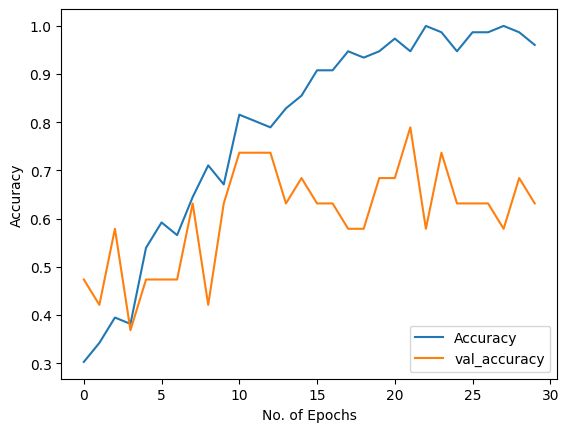

In [ ]:

plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'] ,label='val_accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy")

plt.legend(loc = "lower right")

#Data Augmentation

In [ ]:

datagen = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

 ## Model Creation using different Optimizers after Data Augmentation

## Adam optimizer

In [ ]:

def create_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')  # Output layer
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
input_shape = (224, 224, 3)
num_classes = 3
model_da = create_model(input_shape, num_classes)



In [ ]:
augmented_data = datagen.flow(X_train, y_train, batch_size=32)

In [ ]:
history = model_da.fit(augmented_data, epochs=50,steps_per_epoch=len(X_train) // 25, validation_data=(X_test, y_test))


Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.3087 - loss: 1.7848 - val_accuracy: 0.3333 - val_loss: 1.1610
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.3481 - loss: 1.1175 - val_accuracy: 0.2500 - val_loss: 1.1022
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.3669 - loss: 1.0967 - val_accuracy: 0.2500 - val_loss: 1.1123
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.3587 - loss: 1.0875 - val_accuracy: 0.3333 - val_loss: 1.0886
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.3470 - loss: 1.0926 - val_accuracy: 0.4583 - val_loss: 1.0818
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.3682 - loss: 1.0832 - val_accuracy: 0.2500 - val_loss: 1.0864
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.4283 - loss: 1.0657 - val_accuracy: 0.2500 - val_loss: 1.0977
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.3980 - loss: 1.0414 - val_accuracy: 0.5417 - val_loss: 1.0361
Epoch 9/

In [ ]:

test_loss, test_accuracy = model_da.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 834ms/step - accuracy: 0.7917 - loss: 0.6716
Test accuracy: 0.7917


In [2]:
## Model shows an accuracy of 79% for Adam Optimizer.

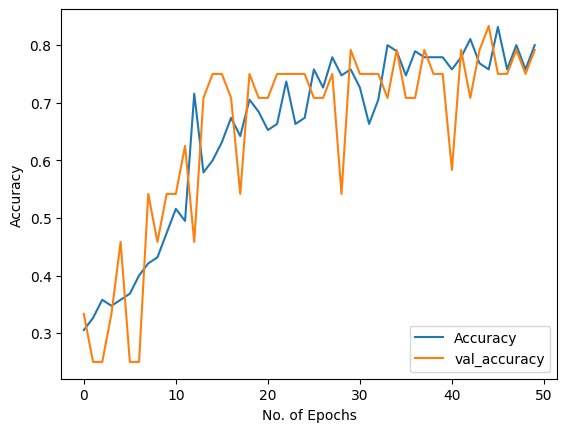

In [ ]:


#Ploting the Accuracy and Validation Accuracy
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'] ,label='val_accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy")

plt.legend(loc = "lower right")

## 2.RMSProp Optimizer

In [ ]:

def create_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')  # Output layer
    ])
    model.compile(optimizer='RMSprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:


input_shape = (224, 224, 3)
num_classes = 3
model_rms = create_model(input_shape, num_classes)

In [ ]:


augmented_data = datagen.flow(X_train, y_train, batch_size=32)

In [ ]:
history = model_rms.fit(augmented_data, epochs=50,steps_per_epoch=len(X_train) // 25, validation_data=(X_test, y_test))


Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.3508 - loss: 2.9151 - val_accuracy: 0.4583 - val_loss: 1.0950
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.3734 - loss: 1.2498 - val_accuracy: 0.3333 - val_loss: 1.1343
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.2902 - loss: 1.1204 - val_accuracy: 0.2500 - val_loss: 1.1015
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.3954 - loss: 1.1391 - val_accuracy: 0.3333 - val_loss: 1.1039
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.2887 - loss: 1.1016 - val_accuracy: 0.3333 - val_loss: 1.1002
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.3497 - loss: 1.0937 - val_accuracy: 0.2500 - val_loss: 1.1004
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.2616 - loss: 1.1072 - val_accuracy: 0.2500 - val_loss: 1.1004
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.3803 - loss: 1.0928 - val_accuracy: 0.5833 - val_loss: 1.0801
Epoch 9/

In [ ]:

test_loss, test_accuracy = model_rms.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7083 - loss: 0.8070
Test accuracy: 0.7083


In [3]:
# Model shows an accuracy of 70% for RMSProp Optimizer

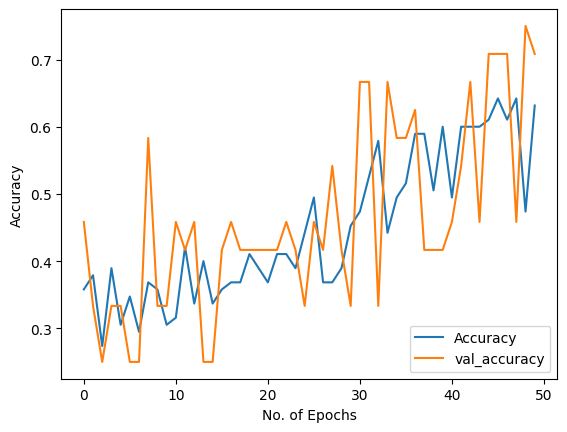

In [ ]:


#Ploting the Accuracy and Validation Accuracy
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'] ,label='val_accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy")

plt.legend(loc = "lower right")

# 3.SGD Optimizer


In [ ]:
def create_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')  # Output layer
    ])
    model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:


input_shape = (224, 224, 3)
num_classes = 3
model_sgd = create_model(input_shape, num_classes)


In [ ]:


augmented_data = datagen.flow(X_train, y_train, batch_size=32)

In [ ]:
history = model_sgd.fit(augmented_data, epochs=50,steps_per_epoch=len(X_train) // 25, validation_data=(X_test, y_test))


Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.3546 - loss: 1.0952 - val_accuracy: 0.2500 - val_loss: 1.1025
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.2432 - loss: 1.1027 - val_accuracy: 0.2500 - val_loss: 1.1047
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.3258 - loss: 1.1039 - val_accuracy: 0.2500 - val_loss: 1.1030
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.3351 - loss: 1.1046 - val_accuracy: 0.2500 - val_loss: 1.1051
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.3574 - loss: 1.0944 - val_accuracy: 0.2500 - val_loss: 1.1033
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 5s/step - accuracy: 0.3681 - loss: 1.0948 - val_accuracy: 0.2500 - val_loss: 1.1030
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.4082 - loss: 1.0968 - val_accuracy: 0.2500 - val_loss: 1.1030
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.4256 - loss: 1.0897 - val_accuracy: 0.2500 - val_loss: 1.1005
Epoch 9/

In [ ]:


test_loss, test_accuracy = model_sgd.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4167 - loss: 1.0313
Test accuracy: 0.4167


In [4]:
# Model shows an accuracy of 41% for SGD Optimizer.

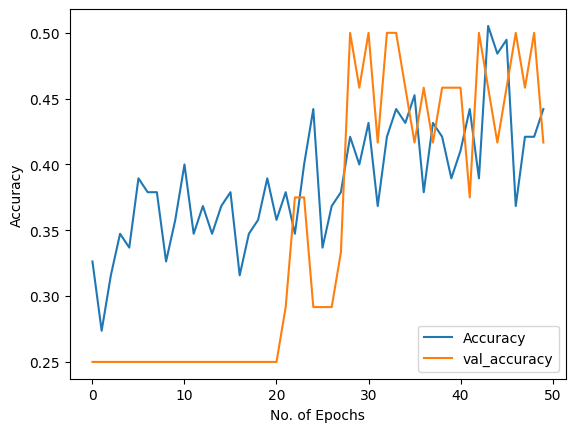

In [ ]:

#Ploting the Accuracy and Validation Accuracy
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'] ,label='val_accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy")

plt.legend(loc = "lower right")

## 4.ADAGRAD optimizer

In [ ]:
def create_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')  # Output layer
    ])
    model.compile(optimizer='Adagrad', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
input_shape = (224, 224, 3)
num_classes = 3
model_adagrad = create_model(input_shape, num_classes)

In [ ]:


augmented_data = datagen.flow(X_train, y_train, batch_size=32)


In [ ]:
history = model_adagrad.fit(augmented_data, epochs=50,steps_per_epoch=len(X_train) // 25, validation_data=(X_test, y_test))


Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.3312 - loss: 1.1110 - val_accuracy: 0.3750 - val_loss: 1.0915
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.3956 - loss: 1.1037 - val_accuracy: 0.4167 - val_loss: 1.0950
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.3640 - loss: 1.1035 - val_accuracy: 0.4167 - val_loss: 1.0962
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.3900 - loss: 1.0906 - val_accuracy: 0.4583 - val_loss: 1.1004
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.3456 - loss: 1.0989 - val_accuracy: 0.2917 - val_loss: 1.1005
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 5s/step - accuracy: 0.3676 - loss: 1.0867 - val_accuracy: 0.2917 - val_loss: 1.0960
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.3338 - loss: 1.1098 - val_accuracy: 0.2500 - val_loss: 1.0995
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.4148 - loss: 1.0785 - val_accuracy: 0.3333 - val_loss: 1.0969
Epoch 9/

In [ ]:
test_loss, test_accuracy = model_adagrad.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5833 - loss: 1.0791
Test accuracy: 0.5833


In [5]:
# Model shows an accuracy of 58% for ADAGRAD Optimizer

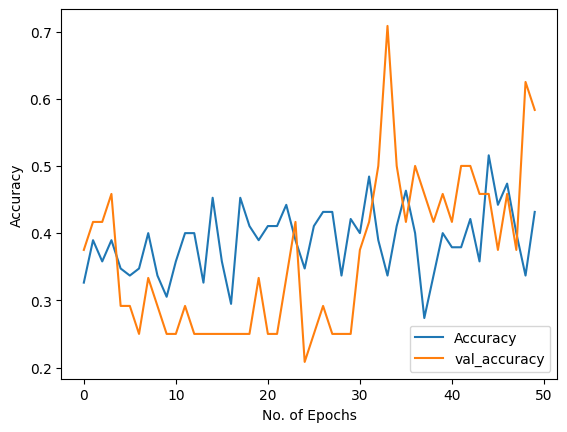

In [ ]:

#Ploting the Accuracy and Validation Accuracy
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'] ,label='val_accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy")

plt.legend(loc = "lower right")


In [ ]:
# Finalising the models with different optimizer

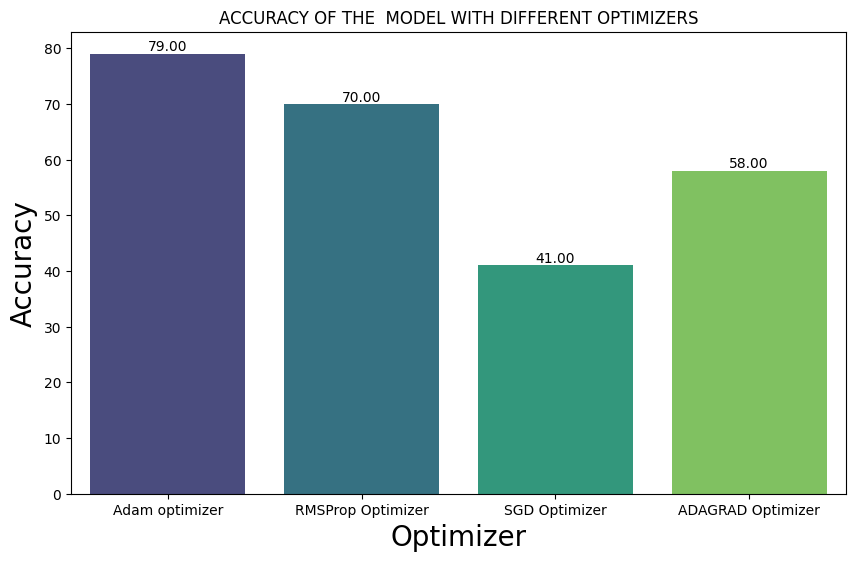

In [8]:
# comparison of accuracy of the models with different optimizer
categories=['Adam optimizer','RMSProp Optimizer','SGD Optimizer','ADAGRAD Optimizer']
values=[79, 70, 41, 58]

# Create DataFrame
data = pd.DataFrame({'Optimizer': categories, 'Accuracy': values})

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Optimizer', y='Accuracy', data=data, palette='viridis')

# Add values on the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

# Add labels and title
plt.xlabel('Optimizer',fontsize=20)
plt.ylabel('Accuracy',fontsize=20)
plt.title('ACCURACY OF THE  MODEL WITH DIFFERENT OPTIMIZERS')

# Show plot
plt.show()


In [ ]:

# make prediction for X_test

y_prediction = model_da.predict(X_test)

leaf_class = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
# get the predicted class for each sample
predicted_classes = np.argmax(y_prediction, axis=1)
print(predicted_classes)

[2 0 2 1 2 2 2 2 0 2 0 0 1 0 0 2 0 0 0 1 0 0 2 0]


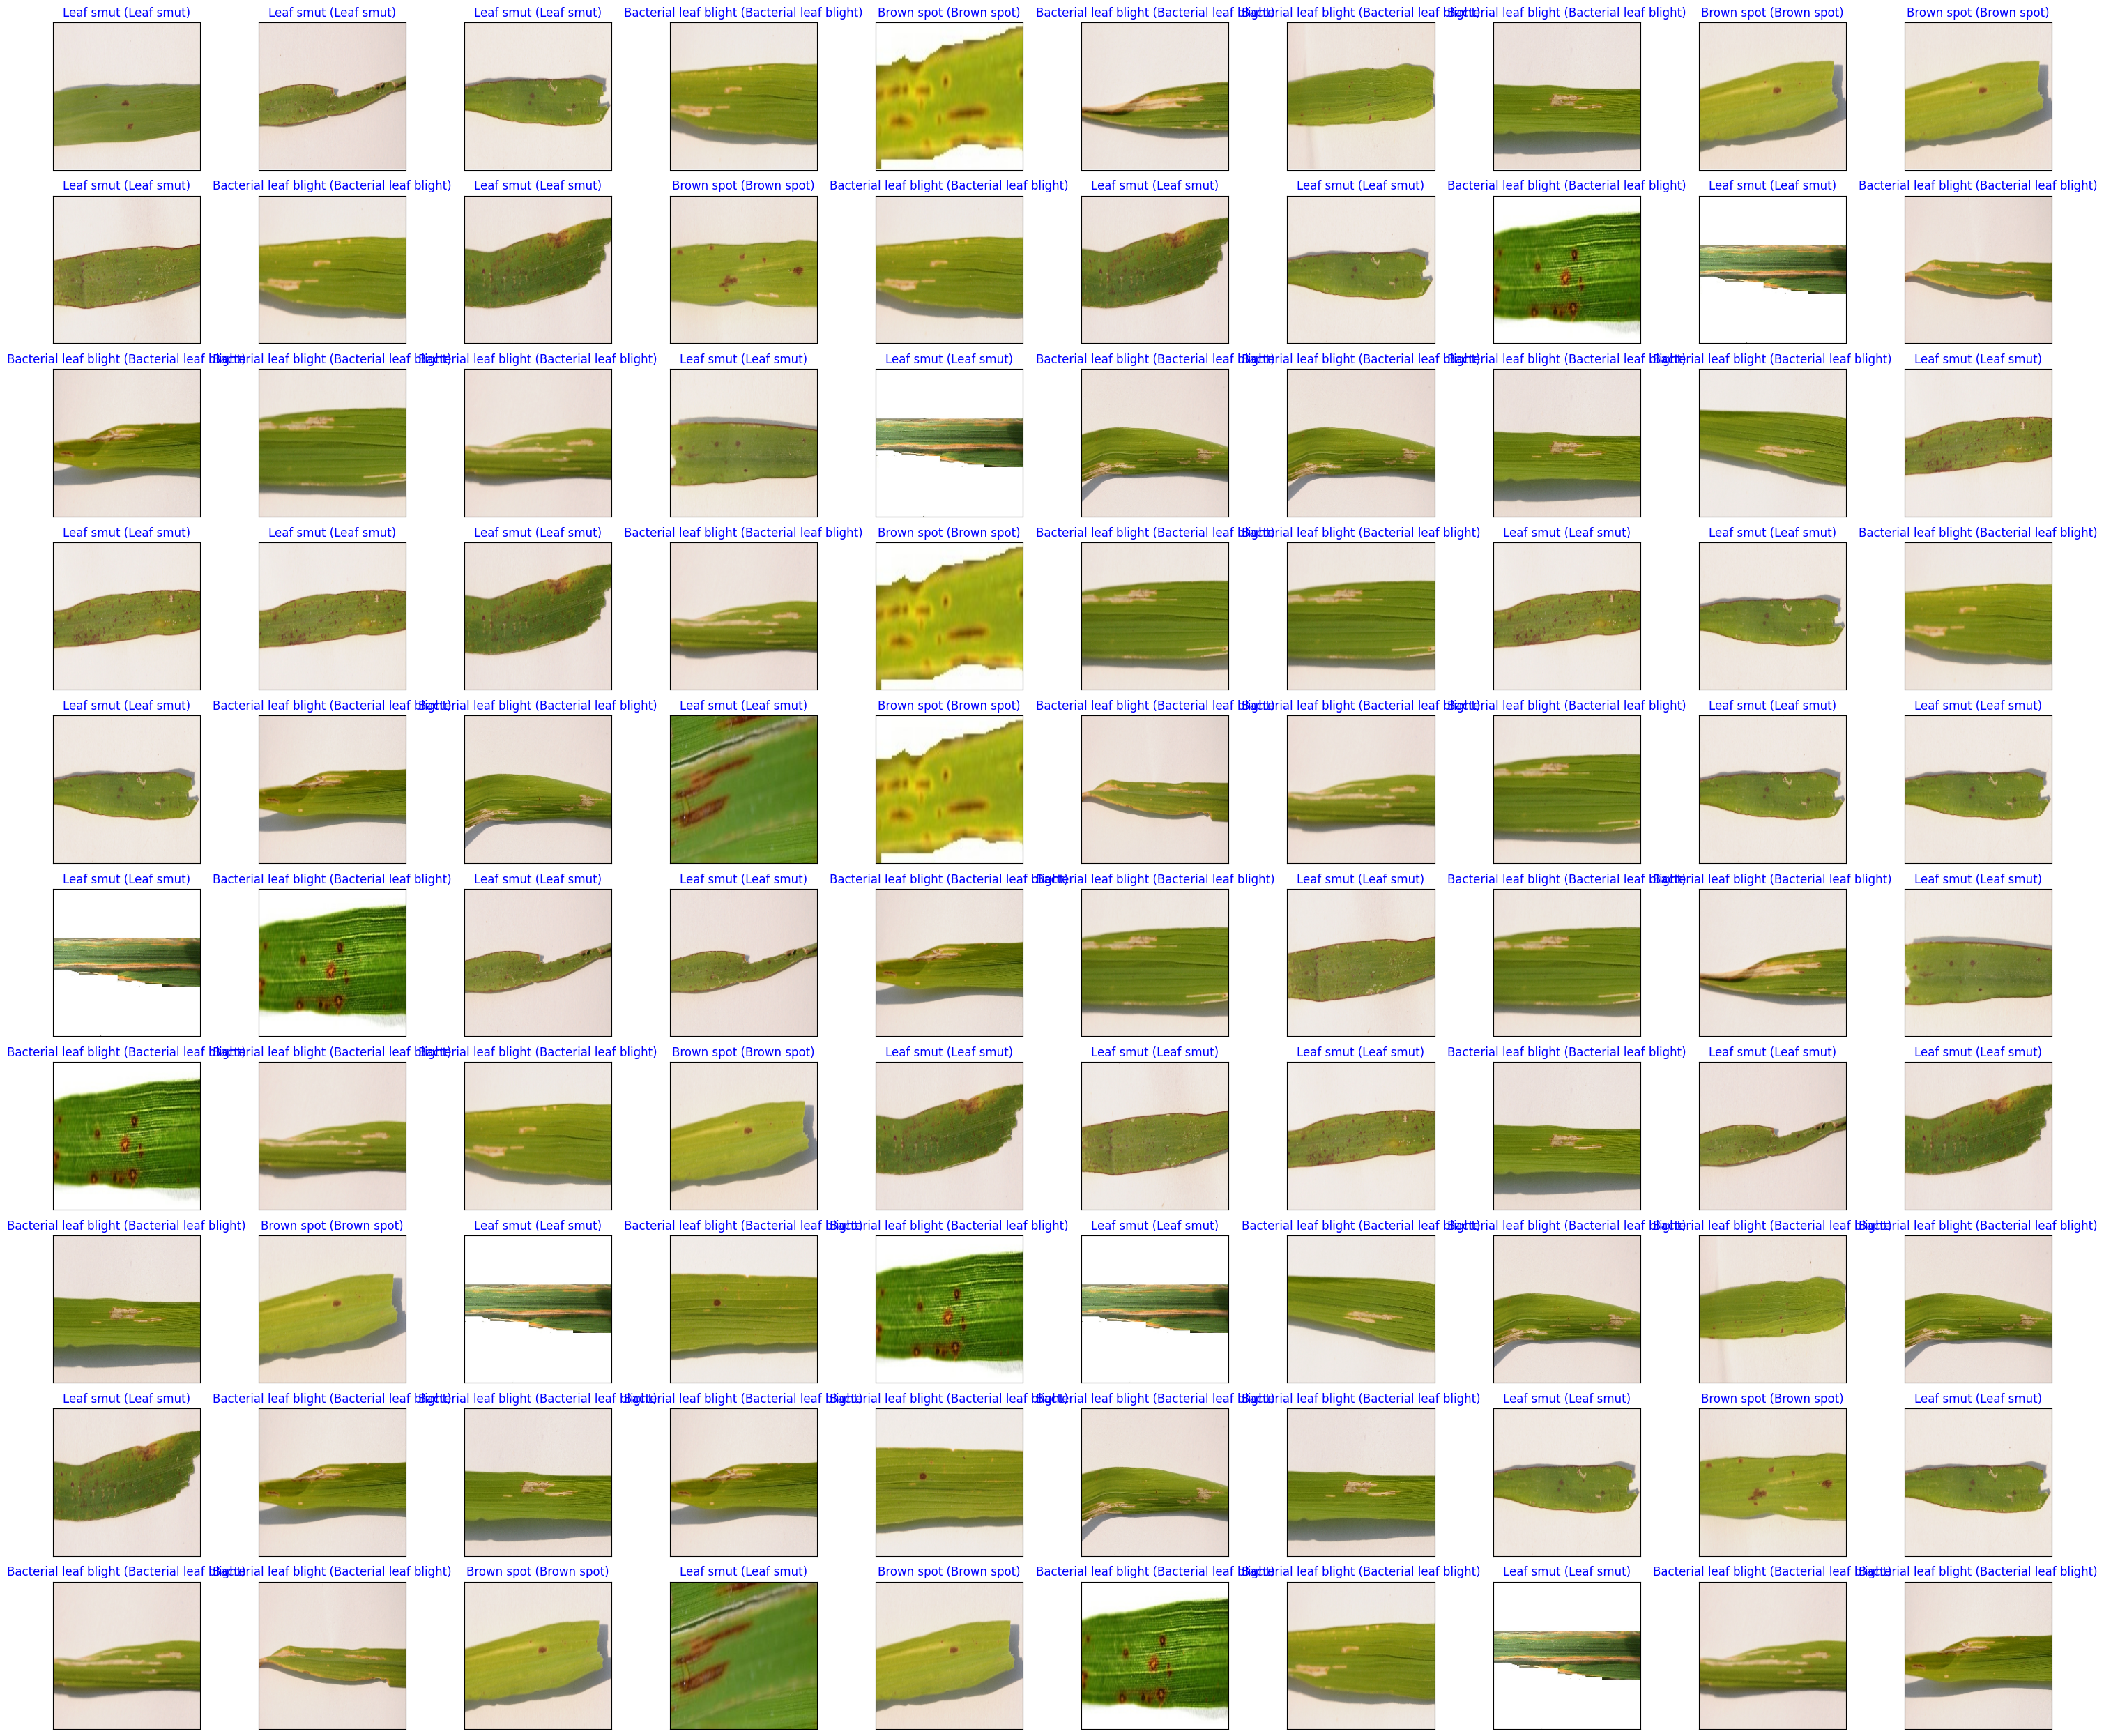

In [ ]:

# Assuming you have 'y_hat' for predictions and 'y_test' for ground truth
# Assuming 'leaf_class' is a list of class labels

# Plot a random sample of test images, their predicted labels, and ground truth
fig = plt.figure(figsize=(30, 25))
for i, idx in enumerate(np.random.choice(X_test.shape[0], size=100, replace=True)):
    ax = fig.add_subplot(10,10, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(X_test[idx]))

    # Assuming 'y_hat' contains the model predictions
    pred_idx = np.argmax(y_prediction[idx])

    true_idx = np.argmax(y_prediction[idx])

    ax.set_title("{} ({})".format(leaf_class[pred_idx], leaf_class[true_idx]),
                 color=("blue" if pred_idx == true_idx else "red"))

plt.tight_layout()

In [ ]:
# For checking the performance ,we took 100 samples and 100 samples were accurately predicted.

In [ ]:
# print Accuracy

test_Accuracy = model_da.evaluate(X_test,y_test)
print(f"Model's Accuracy : {test_Accuracy[1]*100}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7917 - loss: 0.6716
Model's Accuracy : 79.16666865348816



Conclusion:-
The dataset contains 119 jpg images of different diseases.
Here,we had tried 4 Optimizers for model creation in which Adam Optimizer shows the higher accuracy of 79%.Thus we can conclude that it works well for the Rice Leaf Disease Detection.
By using the Adam Optimizer we tried it with the 100 samples of test data and it showed a great output
Thus we can conclude that CNN model with Adam Optimizer is the best one for predicting the Rice Leaf Prediction.


Suggestion :-
As an Asian, Rice plays a major role in our daily diet.Thus production of healthy rice are very important as well.
Some of the suggestions from our Analysis are :-
Taking the prevention method before the disease get worse.
Awareness programs for every farmers throughout the country.
Give proper instructions,effects and prevention methods.
Provide proper pesticides,fertilizers and quality seeds by the Government can make a big change in farmers life.
Risks :-
Data Loading and processing.
High computational time.
Optimizer showing less accuracy.
Less information